In [8]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

print("Wszystko działa!")
# Wczytywanie danych
df = pd.read_csv(r'C:\Users\micha\praca inzynierska\data\apartments_pl_2023_08.csv') 
df.head()

Wszystko działa!


,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,f8524536d4b09a0c8ccc0197ec9d7bde,szczecin,blockOfFlats,63.00,3.0,4.0,10.0,1980.0,53.378933,14.625296,...,0.413,condominium,concreteSlab,NaN,yes,yes,yes,no,yes,415000
1,accbe77d4b360fea9735f138a50608dd,szczecin,blockOfFlats,36.00,2.0,8.0,10.0,NaN,53.442692,14.559690,...,0.205,cooperative,concreteSlab,NaN,no,yes,yes,no,yes,395995
2,8373aa373dbc3fe7ca3b7434166b8766,szczecin,tenement,73.02,3.0,2.0,3.0,NaN,53.452222,14.553333,...,0.280,condominium,brick,NaN,no,no,no,no,no,565000
3,0a68cd14c44ec5140143ece75d739535,szczecin,tenement,87.60,3.0,2.0,3.0,NaN,53.435100,14.532900,...,0.087,condominium,brick,NaN,yes,yes,no,no,yes,640000
4,f66320e153c2441edc0fe293b54c8aeb,szczecin,blockOfFlats,66.00,3.0,1.0,3.0,NaN,53.410278,14.503611,...,0.514,condominium,NaN,NaN,no,no,no,no,no,759000


In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib 

print("KROK 1/5: Filtrowanie i czyszczenie danych.")
warszawa = df[df['city'] == 'warszawa'].copy()

# Wybór kolumn
kolumny_startowe = ['squareMeters', 'rooms', 'floor', 'buildYear', 'latitude', 'longitude']
kolumna_cel = 'price'

# Stworzenie podzbioru
data = warszawa[kolumny_startowe + [kolumna_cel]].copy()

# Czyszczenie danych
data = data.dropna()
data = data[(data['price'] > 100000) & (data['price'] < 10000000)]
print(f"Liczba ofert do nauki po czyszczeniu (tylko Warszawa): {len(data)}")


print("\nKROK 2/5: Inżynieria Cech.")
# Obliczanie odległości od centrum w kilometrach 
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0 
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

palac_lat = 52.2297
palac_lon = 21.0122

data['dist_to_center'] = haversine(data['latitude'], data['longitude'], palac_lat, palac_lon)
data = data.drop(columns=['latitude', 'longitude'])


print("\nKROK 3/5: Metodologia eksperymentu.")
kolumny_cechy = ['squareMeters', 'rooms', 'floor', 'buildYear', 'dist_to_center']
X = data[kolumny_cechy]
y = data[kolumna_cel]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Zbiór treningowy: {len(X_train)} ofert | Zbiór testowy: {len(X_test)} ofert")


print("\nKROK 4/5: Trenowanie modeli...")
print("Trenuję Lasy Losowe.")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Trenuję XGBoost.")
xgb_model = XGBRegressor(n_estimators=100, random_state=42, learning_rate=0.1)
xgb_model.fit(X_train, y_train)


print("\nKROK 5/5: Wyniki eksperymentu")
def sprawdz_model(nazwa, model, X_test, y_test):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"\n--- {nazwa} ---")
    print(f"MAE (Średni błąd):  {int(mae):,} PLN".replace(',', ' '))
    print(f"RMSE (Błąd skrajny): {int(rmse):,} PLN".replace(',', ' '))
    print(f"R² (Dopasowanie):    {r2:.4f}")
    return mae

rf_mae = sprawdz_model("Random Forest", rf_model, X_test, y_test)
xgb_mae = sprawdz_model("XGBoost", xgb_model, X_test, y_test)

if rf_mae < xgb_mae:
    print("\nZWYCIĘZCA: Random Forest! Mylił się średnio na mniejsze kwoty.")
    joblib.dump(rf_model, 'najlepszy_model_sprzedaz.pkl')
else:
    print("\nZWYCIĘZCA: XGBoost! Mylił się średnio na mniejsze kwoty.")
    joblib.dump(xgb_model, 'najlepszy_model_sprzedaz.pkl')
    
print("\nGOTOWE! Zapisano plik 'najlepszy_model_sprzedaz.pkl'.")

KROK 1/5: Filtrowanie i czyszczenie danych.
Liczba ofert do nauki po czyszczeniu (tylko Warszawa): 4187

KROK 2/5: Inżynieria Cech.

KROK 3/5: Metodologia eksperymentu.
Zbiór treningowy: 3349 ofert | Zbiór testowy: 838 ofert

KROK 4/5: Trenowanie modeli...
Trenuję Lasy Losowe.
Trenuję XGBoost.

KROK 5/5: Wyniki eksperymentu

--- Random Forest ---
MAE (Średni błąd):  113 898 PLN
RMSE (Błąd skrajny): 179 081 PLN
R² (Dopasowanie):    0.7990

--- XGBoost ---
MAE (Średni błąd):  121 438 PLN
RMSE (Błąd skrajny): 185 308 PLN
R² (Dopasowanie):    0.7848

ZWYCIĘZCA: Random Forest! Mylił się średnio na mniejsze kwoty.

GOTOWE! Zapisano plik 'najlepszy_model_sprzedaz.pkl'.


Rozpoczynam analizę danych - sprzedaż

Statystyki opisowe zbioru danych (Sprzedaż):


,squareMeters,rooms,floor,buildYear,price,dist_to_center
count,4187.000000,4187.000000,4187.000000,4187.000000,4.187000e+03,4187.000000
mean,61.473929,2.747552,3.776929,1989.036064,9.340271e+05,6.073259
std,23.148277,0.941195,3.047077,28.390289,4.143216e+05,3.239893
min,25.000000,1.000000,1.000000,1851.000000,3.276350e+05,0.000000
25%,45.800000,2.000000,2.000000,1970.000000,6.400000e+05,3.660624
50%,57.000000,3.000000,3.000000,1998.000000,7.999990e+05,5.876395
75%,73.000000,3.000000,5.000000,2013.000000,1.120000e+06,8.269883
max,150.000000,6.000000,29.000000,2023.000000,2.500000e+06,16.317807


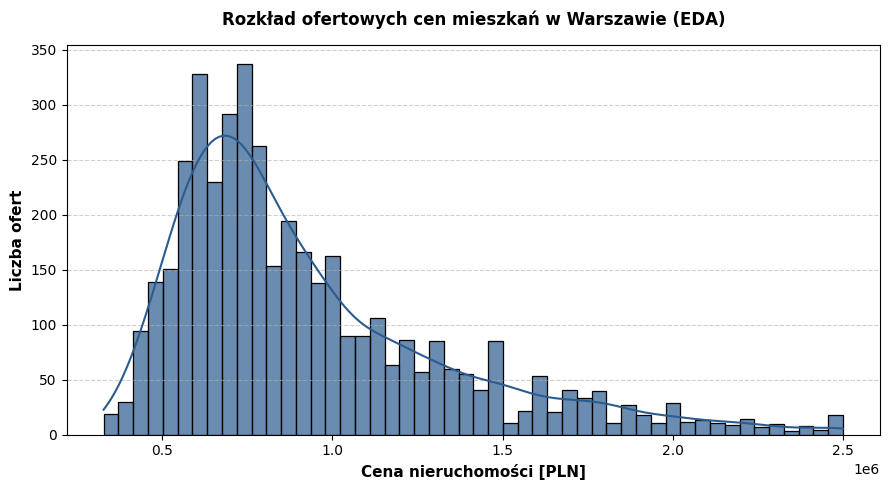

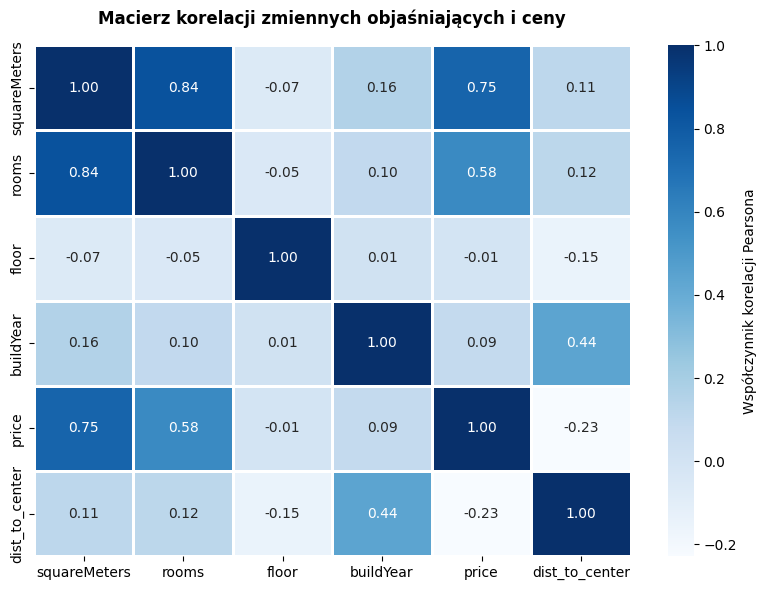


Sukces! Wygenerowano i zapisano wykresy EDA dla sprzedaży.


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Rozpoczynam analizę danych - sprzedaż")

# 1. Statystyki opisowe
print("\nStatystyki opisowe zbioru danych (Sprzedaż):")
display(data.describe())

# 2. Histogram rozkładu cen mieszkań
plt.figure(figsize=(9, 5))
sns.histplot(data['price'], kde=True, color='#2b5c8f', bins=50, edgecolor='black', alpha=0.7)
plt.title('Rozkład ofertowych cen mieszkań w Warszawie (EDA)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Cena nieruchomości [PLN]', fontsize=11, fontweight='bold')
plt.ylabel('Liczba ofert', fontsize=11, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('eda_rozklad_cen_sprzedaz.png', dpi=300)
plt.show()

# 3. Macierz korelacji cech 
plt.figure(figsize=(8, 6))
corr_matrix = data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=0.8, cbar_kws={'label': 'Współczynnik korelacji Pearsona'})
plt.title('Macierz korelacji zmiennych objaśniających i ceny', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_macierz_korelacji_sprzedaz.png', dpi=300)
plt.show()

print("\nSukces! Wygenerowano i zapisano wykresy EDA dla sprzedaży.")

Wizualizacja wyników i ocena modelu.
Do wizualizacji wybrano model o lepszej skuteczności: Random Forest


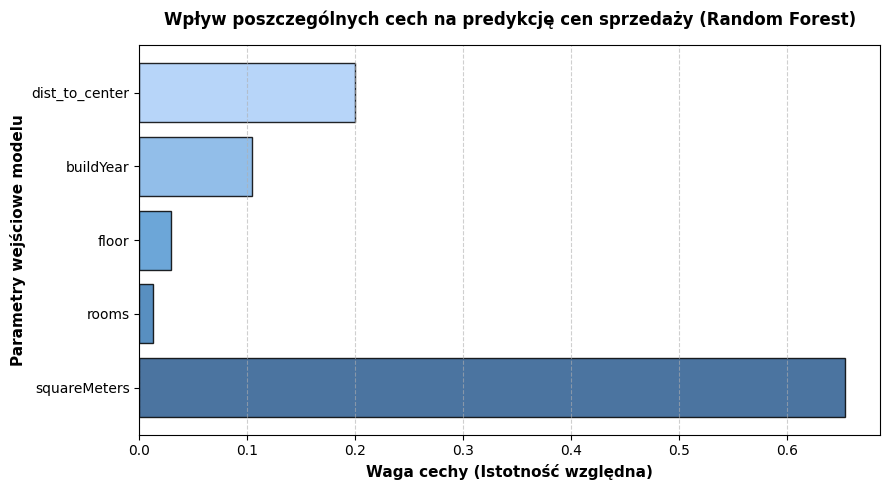

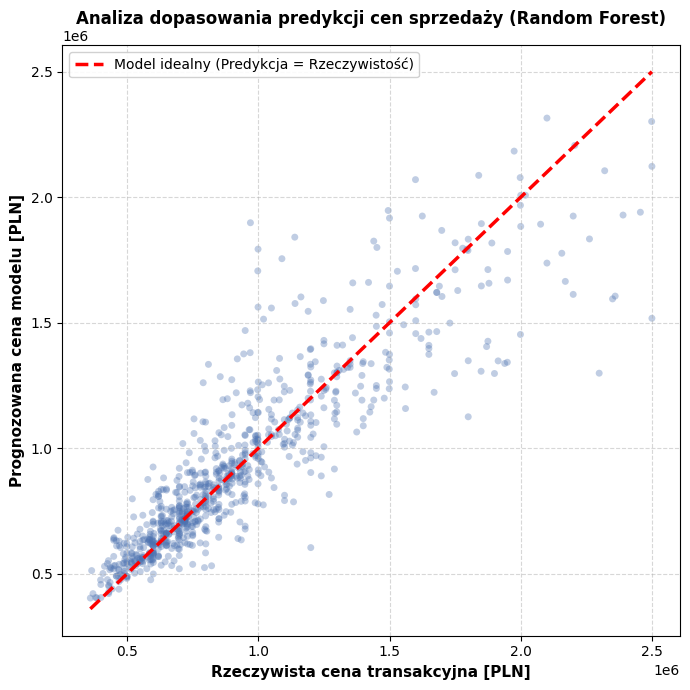


Sukces!


In [11]:
import matplotlib.pyplot as plt

print("Wizualizacja wyników i ocena modelu.")

# Wybór lepszego modelu na podstawie wcześniejszych wyników
wybrany_model = rf_model if rf_mae < xgb_mae else xgb_model
nazwa_modelu = "Random Forest" if rf_mae < xgb_mae else "XGBoost"
print(f"Do wizualizacji wybrano model o lepszej skuteczności: {nazwa_modelu}")

# 1. Wykres istotności cech (Feature Importance)
plt.figure(figsize=(9, 5))
importances = wybrany_model.feature_importances_
kolory = ['#2b5c8f', '#3b7bb5', '#5297d2', '#7fb3e6', '#abcef9']
plt.barh(kolumny_cechy, importances, color=kolory, edgecolor='black', alpha=0.85)
plt.xlabel('Waga cechy (Istotność względna)', fontsize=11, fontweight='bold')
plt.ylabel('Parametry wejściowe modelu', fontsize=11, fontweight='bold')
plt.title(f'Wpływ poszczególnych cech na predykcję cen sprzedaży ({nazwa_modelu})', fontsize=12, fontweight='bold', pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('feature_importance_sprzedaz.png', dpi=300)
plt.show()

# 2. Wykres rozrzutu: Wartości rzeczywiste vs. Predykcje modelu
pred_test = wybrany_model.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred_test, alpha=0.35, color='#4c72b0', edgecolors='none', s=25)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2.5, label='Model idealny (Predykcja = Rzeczywistość)')
plt.xlabel('Rzeczywista cena transakcyjna [PLN]', fontsize=11, fontweight='bold')
plt.ylabel('Prognozowana cena modelu [PLN]', fontsize=11, fontweight='bold')
plt.title(f'Analiza dopasowania predykcji cen sprzedaży ({nazwa_modelu})', fontsize=12, fontweight='bold', pad=15)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('actual_vs_predicted_sprzedaz.png', dpi=300)
plt.show()

print("\nSukces!")

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import joblib 

print("KROK 1/4: Wczytanie i czyszczenie danych o wynajmie.")
df_rent = pd.read_csv(r'C:\Users\micha\praca inzynierska\data\wynajem_pl.csv')
warszawa_rent = df_rent[df_rent['city'].str.lower() == 'warszawa'].copy()

kolumny_startowe = ['squareMeters', 'rooms', 'floor', 'buildYear', 'latitude', 'longitude']
kolumna_cel = 'price' 

data_rent = warszawa_rent[kolumny_startowe + [kolumna_cel]].copy()
data_rent = data_rent.dropna()
data_rent = data_rent[(data_rent['price'] >= 1500) & (data_rent['price'] <= 30000)]
print(f"Liczba ofert wynajmu do nauki: {len(data_rent)}")

print("\nKROK 2/4: Feature Engineering (Odległość od centrum).")
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0 
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

palac_lat = 52.2297
palac_lon = 21.0122

data_rent['dist_to_center'] = haversine(data_rent['latitude'], data_rent['longitude'], palac_lat, palac_lon)
data_rent = data_rent.drop(columns=['latitude', 'longitude'])

print("\nKROK 3/4: Trenowanie modelu wynajmu.")
kolumny_cechy = ['squareMeters', 'rooms', 'floor', 'buildYear', 'dist_to_center']
X = data_rent[kolumny_cechy]
y = data_rent[kolumna_cel]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_rent = RandomForestRegressor(n_estimators=100, random_state=42)
model_rent.fit(X_train, y_train)

pred_rent = model_rent.predict(X_test)
mae_rent = mean_absolute_error(y_test, pred_rent)
print(f"Średni błąd szacowania czynszu (MAE): {int(mae_rent)} PLN miesięcznie")

print("\nKROK 4/4: Zapisanie modelu wynajmu.")
joblib.dump(model_rent, 'najlepszy_model_wynajem.pkl')
print("Zapisano model wynajmu.")

KROK 1/4: Wczytanie i czyszczenie danych o wynajmie.
Liczba ofert wynajmu do nauki: 2395

KROK 2/4: Feature Engineering (Odległość od centrum).

KROK 3/4: Trenowanie modelu wynajmu.
Średni błąd szacowania czynszu (MAE): 805 PLN miesięcznie

KROK 4/4: Zapisanie modelu wynajmu.
Zapisano model wynajmu.


Rozpoczynam analizę danych - wynajem.

Statystyki opisowe zbioru danych (Najem):


,squareMeters,rooms,floor,buildYear,price,dist_to_center
count,2395.000000,2395.000000,2395.000000,2395.000000,2395.000000,2395.000000
mean,64.774939,2.664301,3.943633,1995.450522,5482.986221,4.663087
std,27.461557,0.974636,3.091300,29.407281,3060.682275,2.891233
min,25.000000,1.000000,1.000000,1873.000000,2400.000000,0.003020
25%,44.000000,2.000000,2.000000,1980.000000,3450.000000,2.462455
50%,56.000000,2.000000,3.000000,2007.000000,4500.000000,4.246603
75%,80.000000,3.000000,5.000000,2017.000000,6500.000000,6.293582
max,150.000000,6.000000,23.000000,2023.000000,20000.000000,15.625683


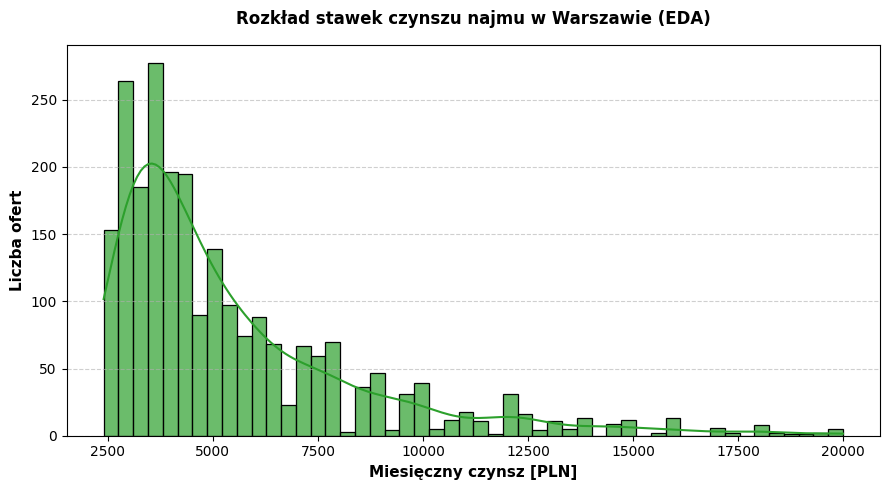

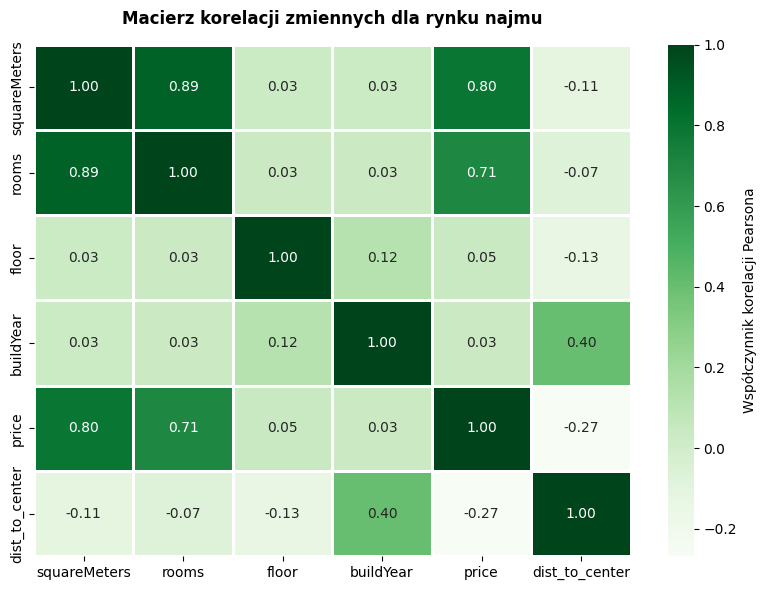


Sukces! Wygenerowano i zapisano wykresy EDA dla wynajmu.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Rozpoczynam analizę danych - wynajem.")

# 1. Statystyki opisowe
print("\nStatystyki opisowe zbioru danych (Najem):")
display(data_rent.describe())

# 2. Histogram rozkładu czynszów
plt.figure(figsize=(9, 5))
sns.histplot(data_rent['price'], kde=True, color='#2ca02c', bins=50, edgecolor='black', alpha=0.7)
plt.title('Rozkład stawek czynszu najmu w Warszawie (EDA)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Miesięczny czynsz [PLN]', fontsize=11, fontweight='bold')
plt.ylabel('Liczba ofert', fontsize=11, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('eda_rozklad_czynsz_wynajem.png', dpi=300)
plt.show()

# 3. Macierz korelacji dla wynajmu
plt.figure(figsize=(8, 6))
corr_matrix_rent = data_rent.corr()
sns.heatmap(corr_matrix_rent, annot=True, cmap='Greens', fmt='.2f', linewidths=0.8, cbar_kws={'label': 'Współczynnik korelacji Pearsona'})
plt.title('Macierz korelacji zmiennych dla rynku najmu', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_macierz_korelacji_wynajem.png', dpi=300)  # Usunięto niepoprawny argument fontsize
plt.show()

print("\nSukces! Wygenerowano i zapisano wykresy EDA dla wynajmu.")

Wizualizacja wyników i ocena modelu.


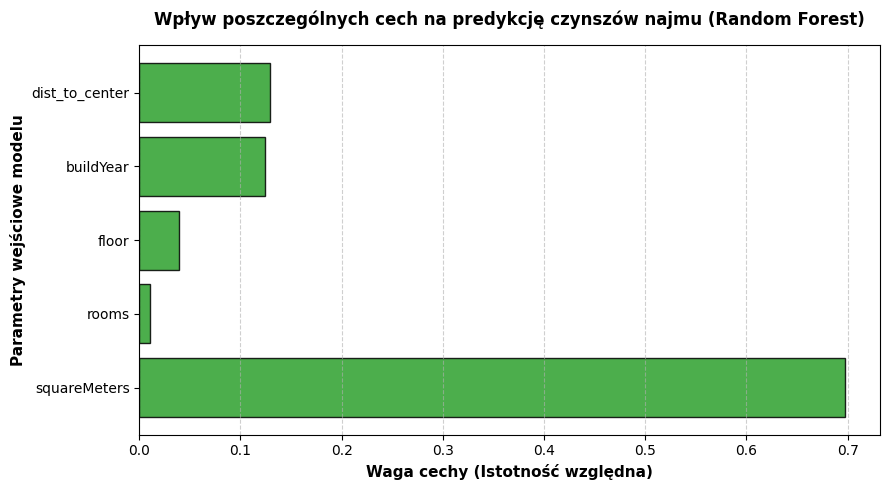

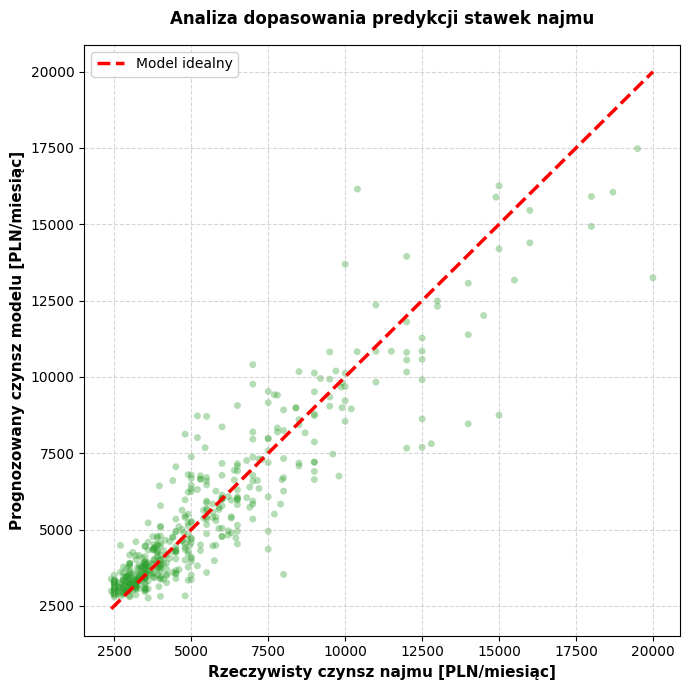


Wygenerowano i zapisano wykresy dla modelu wynajmu!


In [14]:
import matplotlib.pyplot as plt

print("Wizualizacja wyników i ocena modelu.")

# 1. Istotność cech dla wynajmu
plt.figure(figsize=(9, 5))
importances_rent = model_rent.feature_importances_
plt.barh(kolumny_cechy, importances_rent, color='#2ca02c', edgecolor='black', alpha=0.85)
plt.xlabel('Waga cechy (Istotność względna)', fontsize=11, fontweight='bold')
plt.ylabel('Parametry wejściowe modelu', fontsize=11, fontweight='bold')
plt.title('Wpływ poszczególnych cech na predykcję czynszów najmu (Random Forest)', fontsize=12, fontweight='bold', pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('feature_importance_wynajem.png', dpi=300)
plt.show()

# 2. Wykres Actual vs Predicted dla wynajmu
plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred_rent, alpha=0.35, color='#2ca02c', edgecolors='none', s=25)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2.5, label='Model idealny')
plt.xlabel('Rzeczywisty czynsz najmu [PLN/miesiąc]', fontsize=11, fontweight='bold')
plt.ylabel('Prognozowany czynsz modelu [PLN/miesiąc]', fontsize=11, fontweight='bold')
plt.title('Analiza dopasowania predykcji stawek najmu', fontsize=12, fontweight='bold', pad=15)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('actual_vs_predicted_wynajem.png', dpi=300)
plt.show()

print("\nWygenerowano i zapisano wykresy dla modelu wynajmu!")